# TP53 (P04637) — latent‑driver epistasis vs distance‑matched controls


## §0 — Config

In [ ]:
!pip install -q Biopython sentencepiece transformers
!pip install -q https://github.com/debbiemarkslab/EVcouplings/archive/develop.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.6 MB/s eta 0:00:00
     \ 18.6 MB 15.1 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 21.4 MB/s eta 0:00:00


In [ ]:
import gc, math, os
import re
import random
import warnings
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.mixture import GaussianMixture
from torch.utils.data import Dataset, DataLoader
from transformers import T5EncoderModel, T5Tokenizer
from evcouplings.align import Alignment, read_fasta

pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

In [ ]:
import ast, glob

UNIPROT = 'P04637'
WT = (
    "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP"
    "DEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLQSGTAK"
    "SVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHE"
    "RCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNS"
    "SCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELP"
    "PGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPG"
    "GSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD")
L = len(WT); assert L == 393
AA = "ACDEFGHIKLMNPQRSTVWY"

# proposed epistatic links: A -> [B, ...]
positions = {285:[271,287], 348:[349], 160:[161], 175:[248,273],
             273:[248], 280:[287], 282:[248]}

# --- where the pre-computed feature CSVs live (READ path) ---
OUT_DIR = '/content/drive/MyDrive/D2D_paper/review_CSBJ/latent_pairs/'

# feature-file names inside OUT_DIR (edit if yours differ; §2 lists what's actually there)
FEAT_FILES = {'epistatic':'D2D_features_epistatic_TP53.csv',
              'control'  :'D2D_features_control_TP53.csv',
              'singles'  :'D2D_features_singles_TP53.csv'}

# --- control-generation knobs ---
DBD_REGION   = (94, 312)
LATENT_BUFFER= 2
SEED         = 7
# Zn-coordinating + structurally critical DBD residues. Excluded from the control pool
# only if EXCLUDE_CRITICAL=True. NOTE: turning this ON changes ctrl_map, so you must
# RECOMPUTE features for the new controls (§2-alt). Leave False to match features already in OUT_DIR.
CRITICAL_POS   = {176, 178, 179, 238, 242}
EXCLUDE_CRITICAL = False

# the 12 validated latent drivers
latent_true = ['P04637_E285K:E271K','P04637_E285K:E271Q','P04637_E285Q:E271K','P04637_E285Q:E271Q',
 'P04637_E285K:E287D','P04637_E285K:E287K','P04637_E285K:E287Q','P04637_M160I:A161S','P04637_M160I:A161T',
 'P04637_R280K:E287D','P04637_R280K:E287Q','P04637_R280T:E287D']

category_to_color = {'160161':'red','175248':'green','175273':'blue','273248':'purple',
 '280287':'orange','282248':'cyan','285271':'black','285287':'yellow','348349':'pink'}

epi_pairs = [(a, b) for a, bs in positions.items() for b in bs]
latent_positions = set(positions.keys()) | {b for bs in positions.values() for b in bs}
print("epistatic pairs:", epi_pairs)

epistatic pairs: [(285, 271), (285, 287), (348, 349), (160, 161), (175, 248), (175, 273), (273, 248), (280, 287), (282, 248)]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def normalize_minmax(data):
    """Min-max normalize a numpy array."""
    dmin, dmax = np.min(data), np.max(data)
    if dmax == dmin:
        return np.zeros_like(data)
    return (data - dmin) / (dmax - dmin)



def read_a3m(fileobj, inserts="first"):
    """
    Read an alignment in compressed a3m format and expand into a2m format.

    Parameters
    ----------
    fileobj : file-like object
        A3M alignment file.
    inserts : {'first', 'delete'}
        Keep inserts in first sequence, or delete any insert column.

    Returns
    -------
    OrderedDict
        Sequences in alignment (key: ID, value: sequence).
    """
    seqs = OrderedDict()

    for i, (seq_id, seq) in enumerate(read_fasta(fileobj)):
        seq = seq.replace(".", "")

        if inserts == "first":
            if i == 0:
                uppercase_cols = [
                    j for j, c in enumerate(seq)
                    if c == c.upper() or c == "-"
                ]
                gap_template = np.array(["."] * len(seq))
            else:
                uppercase_chars = [
                    c for c in seq if c == c.upper() or c == "-"
                ]
                filled = np.copy(gap_template)
                filled[uppercase_cols] = uppercase_chars
                seq = "".join(filled)

        elif inserts == "delete":
            seq = "".join(c for c in seq if c == c.upper() and c != ".")
        else:
            raise ValueError(f"Invalid option for inserts: {inserts}")

        seqs[seq_id] = seq

    return seqs


def embed_sequences(sequences, tokenizer, model, device, batch_size=5):
    """Compute ProtT5 embeddings for a list of amino-acid sequences.

    Parameters
    ----------
    sequences : list[str]
        Space-separated AA sequences (non-standard AAs replaced with X).
    tokenizer : T5Tokenizer
    model : T5EncoderModel
    device : torch.device
    batch_size : int

    Returns
    -------
    list[np.ndarray]
        Per-residue embeddings, each of shape (seq_len, 1024).
    """
    embeddings = []

    for start in range(0, len(sequences), batch_size):
        batch = sequences[start:start + batch_size]
        #ids = tokenizer.batch_encode_plus(batch, add_special_tokens=True, padding='longest')
        ids = tokenizer(batch, add_special_tokens=True, padding='longest')
        input_ids = torch.tensor(ids['input_ids']).to(device)
        attention_mask = torch.tensor(ids['attention_mask']).to(device)

        with torch.no_grad():
            output = model(input_ids=input_ids, attention_mask=attention_mask)
            emb_batch = output.last_hidden_state.cpu().numpy()

        for seq_num in range(len(emb_batch)):
            seq_len = (attention_mask[seq_num] == 1).sum().item()
            embeddings.append(emb_batch[seq_num][:seq_len - 1])  # exclude EOS token

        del attention_mask, input_ids
        gc.collect()

    return embeddings

In [ ]:
class Classifier2L(nn.Module):
    def __init__(self, hidden, hidden2, dropout=0):
        super(Classifier2L, self).__init__()
        self.hidden = hidden
        self.hidden2 = hidden2
        self.num_feature = 2200
        self.dropout = dropout
        self.batchnorm1 = nn.BatchNorm1d(self.hidden)
        self.batchnorm2 = nn.BatchNorm1d(self.hidden2)

        self.layer_1 = nn.Linear(self.num_feature,  self.hidden)
        self.layer_2 = nn.Linear( self.hidden, self.hidden2)
        self.layer_3 = nn.Linear( self.hidden2, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.batchnorm1(x)
        x= self.dropout(x)
        x = self.relu(x)

        x = self.layer_2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        x= self.dropout(x)

        x = self.layer_3(x)
        #x = self.sigmoid(x)

        return x


    def compute_l1_loss(self, w):
        return torch.abs(w).sum()

    def compute_l2_loss(self, w):
        return torch.square(w).sum()


class ClassifierDataset(Dataset):

    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__ (self):
        return len(self.X_data)

In [ ]:
def load_and_filter_msa(msa_filepath, min_identity=0.5, max_gap_frac=0.3,
                        fallback_identity=0.2, fallback_gap_frac=0.7,
                        min_sequences=15):
    """Load an MSA from an a3m file and filter by identity and gap fraction.

    If the initial filtering yields fewer than `min_sequences` sequences,
    falls back to more permissive thresholds.

    Parameters
    ----------
    msa_filepath : str
        Path to the .a3m MSA file.
    min_identity : float
        Minimum sequence identity to the first sequence.
    max_gap_frac : float
        Maximum fraction of gap characters per sequence.
    fallback_identity : float
        Relaxed identity threshold if too few sequences remain.
    fallback_gap_frac : float
        Relaxed gap threshold if too few sequences remain.
    min_sequences : int
        Minimum number of sequences before triggering fallback.

    Returns
    -------
    Alignment
        Filtered EVcouplings Alignment object.
    """
    with open(msa_filepath, "r") as infile:
        next(infile)  # skip header
        seqs_dict = read_a3m(infile, inserts="delete")

    aln = Alignment.from_dict(seqs_dict)
    print(f"Raw alignment: {aln.N} sequences, length {aln.L}")

    ident_perc = aln.identities_to(aln.matrix[0])
    gap_fracs = aln.count(axis="seq", char="-")

    def _filter(ident_thresh, gap_thresh):
        return [
            i for i in range(len(ident_perc))
            if ident_perc[i] > ident_thresh and gap_fracs[i] <= gap_thresh
        ]

    keep = _filter(min_identity, max_gap_frac)
    if len(keep) < min_sequences:
        print(f"Only {len(keep)} sequences after strict filter, using relaxed thresholds")
        keep = _filter(fallback_identity, fallback_gap_frac)

    aln_filtered = aln.select(sequences=keep)
    print(f"Filtered alignment: {aln_filtered.N} sequences")
    return aln_filtered

def _prepare_msa_sequences(aln):
    """Convert alignment matrix rows into space-separated, upper-cased sequences."""
    seqs = []
    for row_idx in range(len(aln)):
        chars = [c.upper() for c in aln.matrix[row_idx].tolist()]
        seq_str = " ".join(chars)
        seq_str = re.sub(r"[-.UZOB]", "X", seq_str)
        seqs.append(seq_str)
    return seqs


def _embed_single_mutation(mut_sequence, tokenizer, model, device, pool):
    """Embed a single mutant sequence and apply max-pooling."""
    chars = [c for c in mut_sequence]
    seq_str = " ".join(chars)
    seq_str = re.sub(r"[-.]", "X", seq_str)

    #ids = tokenizer.batch_encode_plus([seq_str], add_special_tokens=True, padding='longest')
    ids = tokenizer([seq_str], add_special_tokens=True, padding='longest')
    input_ids = torch.tensor(ids['input_ids']).to(device)
    attention_mask = torch.tensor(ids['attention_mask']).to(device)

    with torch.no_grad():
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        emb = output.last_hidden_state.cpu().numpy()
        seq_len = (attention_mask == 1).sum().item()
        seq_emd = emb[:, :seq_len - 1, :]

    seq_emd = pool(torch.tensor(seq_emd)).numpy()

    del input_ids, attention_mask
    gc.collect()

    return seq_emd[0]  # shape: (L, reduced_dim)


def calculation_WT_MUT(uniprot, all_mutations, msa_path, tokenizer, model, device, pool):
    """Calculate D2D features: WT vs mutant log-likelihood differences.

    Parameters
    ----------
    uniprot : str
        UniProt accession.
    all_mutations : pd.DataFrame
        Must contain columns: 'mut_sequence', 'mutant'.
    msa_path : str
        Directory containing .a3m MSA files.
    tokenizer, model : ProtT5 tokenizer and encoder.
    device : torch.device
    pool : nn.MaxPool1d
        Pooling layer for dimensionality reduction.

    Returns
    -------
    tuple of (log_probs, mutation_labels, feature_differences)
    """
    print(f"Processing {uniprot}")

    # --- Load and filter MSA ---
    msa_file = os.path.join(msa_path, f"{uniprot}.a3m")
    if not os.path.isfile(msa_file):
        raise FileNotFoundError(f"MSA not found: {msa_file}")

    aln = load_and_filter_msa(msa_file)

    # --- Embed WT MSA sequences ---
    msa_sequences = _prepare_msa_sequences(aln)
    batch_size = 5 if aln.L < 501 else 1
    wt_embeddings = embed_sequences(msa_sequences, tokenizer, model, device, batch_size)

    arr_WT = np.array(wt_embeddings)
    arr_WT = pool(torch.tensor(arr_WT)).numpy()
    print(f"WT embedding shape: {arr_WT.shape}")

    # Save ProtT5 representations
    save_path = f'/content/drive/MyDrive/D2D_paper/review_CSBJ/{uniprot}_MSA_protT5_20D.npz'
    np.savez_compressed(save_path, arr=arr_WT)

    # --- Fit per-position GMMs on WT ---
    n_positions = arr_WT.shape[1]
    gmm_models = {}
    thresholds = np.zeros(n_positions)
    wt_diffs = np.zeros(n_positions)

    for col in range(n_positions):
        col_data = arr_WT[:, col]#.reshape(-1, 1)
        gmm = GaussianMixture(n_components=1).fit(col_data)
        gmm_models[col] = gmm

        densities = gmm.score_samples(col_data)
        thresholds[col] = np.percentile(densities, 99)
        wt_diffs[col] = densities[0] - thresholds[col]

    # --- Compute features for each mutation ---
    log_probs_out = []
    mutations_out = []
    features_out = []

    for _, mut_row in all_mutations.iterrows():
        # Embed the mutant
        mut_emb = _embed_single_mutation(
            mut_row['mut_sequence'], tokenizer, model, device, pool
        )

        # Replace WT first row with mutant embedding
        arr_mut = arr_WT.copy()
        arr_mut[0] = mut_emb

        # Per-position mutant log-likelihood differences
        mut_diffs = np.zeros(n_positions)
        for col in range(n_positions):
            density = gmm_models[col].score_samples(arr_mut[0, col].reshape(1, -1))
            mut_diffs[col] = density.item() - thresholds[col]

        # Log-probability (quality of fit) at mutation position(s)
        mutant_label = str(mut_row['mutant'])
        if ':' in mutant_label:
            # Multiple mutations (e.g. "A10C:G20T")
            positions = [int(p[1:-1]) - 1 for p in mutant_label.split(':')]
            avg_log_prob = np.mean([
                np.mean(gmm_models[pos].score_samples(arr_WT[:, pos]))
                for pos in positions
            ])
        else:
            pos = int(mutant_label[1:-1]) - 1
            avg_log_prob = np.mean(
                gmm_models[pos].score_samples(arr_WT[:, pos])
            )

        mutations_out.append(f"{uniprot}_{mutant_label}")
        log_probs_out.append(round(avg_log_prob, 3))
        features_out.append((wt_diffs - mut_diffs).tolist())

    return log_probs_out, mutations_out, features_out

## §1 — Pairs: epistatic + distance‑matched controls

`subst_download_new` / `substitute_mod` reconstructed from `test.ipynb`. Controls are exact‑distance matched, drawn from the DBD, excluded within ±`LATENT_BUFFER` of any latent site (and of the Zn/critical residues if `EXCLUDE_CRITICAL`), kept disjoint.

In [ ]:
def apply_mut(seq, pos, alt): return seq[:pos-1] + alt + seq[pos:]

def subst_download_new(uniprot, start, end, wt=WT):
    rows=[]
    for pos in range(start, end):
        wt_aa = wt[pos-1]
        for alt in AA:
            if alt != wt_aa:
                rows.append({'mutant':f"{wt_aa}{pos}{alt}", 'mut_sequence':apply_mut(wt,pos,alt)})
    return pd.DataFrame(rows)

def substitute_mod(uniprot, first_mutant, first_seq, start, end, wt=WT):
    rows=[]
    for pos in range(start, end):
        wt_aa = wt[pos-1]
        for alt in AA:
            if alt != wt_aa:
                rows.append({'mutant':f"{first_mutant}:{wt_aa}{pos}{alt}",
                             'mut_sequence':apply_mut(first_seq,pos,alt)})
    return pd.DataFrame(rows)

def make_controls(epi_pairs, latent, L, region=DBD_REGION, seed=SEED,
                  buffer=LATENT_BUFFER, critical=CRITICAL_POS, exclude_critical=EXCLUDE_CRITICAL):
    rng = random.Random(seed)
    excluded = {p+k for p in latent for k in range(-buffer, buffer+1)}
    if exclude_critical:
        excluded |= set(critical)
    used, out = set(), []
    for (a, b) in epi_pairs:
        d = abs(a-b); cands=[]
        for lo, hi in [region, (1, L)]:
            cands = [(A, A+d) for A in range(lo, hi-d+1)
                     if A not in excluded and A+d not in excluded
                     and A not in used and A+d not in used]
            if cands: break
        (A, B) = rng.sample(cands, 1)[0]; used |= {A, B}
        out.append({'epi_A':a,'epi_B':b,'dist':d,'ctrl_A':A,'ctrl_B':B})
    return pd.DataFrame(out)

ctrl_map = make_controls(epi_pairs, latent_positions, L)
ctrl_list = list(zip(ctrl_map['ctrl_A'], ctrl_map['ctrl_B']))
epi2ctrl  = {f"{r.epi_A}_{r.epi_B}": f"{r.ctrl_A}_{r.ctrl_B}" for _, r in ctrl_map.iterrows()}
ctrl_map

,epi_A,epi_B,dist,ctrl_A,ctrl_B
0,285,271,14,193,207
1,285,287,2,132,134
2,348,349,1,216,217
3,160,161,1,311,312
4,175,248,73,105,178
5,175,273,98,104,202
6,273,248,25,242,267
7,280,287,7,122,129
8,282,248,34,166,200


In [ ]:
def build_doubles(pairs, group, wt=WT):
    frames=[]
    for (a,b) in pairs:
        for _, m in subst_download_new(UNIPROT, a, a+1, wt).iterrows():
            df2 = substitute_mod(UNIPROT, m['mutant'], m['mut_sequence'], b, b+1, wt)
            df2['posA'], df2['posB'] = a, b
            frames.append(df2)
    out = pd.concat(frames, ignore_index=True)
    out['group'] = group
    out['pair']  = out['posA'].astype(str)+'_'+out['posB'].astype(str)
    return out

def build_singles(pairs, wt=WT):
    posset = sorted({p for pr in pairs for p in pr})
    out = pd.concat([subst_download_new(UNIPROT, p, p+1, wt) for p in posset], ignore_index=True)
    out['pos'] = out['mutant'].str[1:-1].astype(int)
    return out

# only needed for the §2-alt recompute path; harmless to build regardless
epi_doubles  = build_doubles(epi_pairs,  'epistatic')
ctrl_doubles = build_doubles(ctrl_list,  'control')
singles_mut  = build_singles(epi_pairs + ctrl_list)
print(f"epistatic {len(epi_doubles)} | control {len(ctrl_doubles)} | singles {len(singles_mut)} mutants")

## §2 — Read pre‑computed D2D features from `OUT_DIR`  ← default path

Loads the feature CSVs you already generated (no ProtT5 needed).

In [ ]:
def _parse_feat(x):
    if isinstance(x, (list, tuple)): return [float(v) for v in x]
    s = str(x).strip()
    try:
        return [float(v) for v in ast.literal_eval(s)]
    except Exception:
        return [float(v) for v in s.strip('[]').split(',') if v.strip() != '']

EPI_SET  = {f"{a}_{b}" for (a,b) in epi_pairs}
CTRL_SET = {f"{a}_{b}" for (a,b) in ctrl_list}

def load_features(path):
    df = pd.read_csv(path)
    fcol = next((c for c in ('features','Log dif','log_dif','fl_dif') if c in df.columns), None)
    if fcol is None:
        raise ValueError(f"No feature column found in {os.path.basename(path)}; columns = {list(df.columns)}")
    df['features'] = df[fcol].map(_parse_feat)
    if 'mutation' not in df.columns:
        df['mutation'] = UNIPROT + '_' + df['mutant'].astype(str)
    body = df['mutation'].str.split('_', n=1).str[-1]
    if 'posA' not in df.columns:
        df['posA'] = body.map(lambda s: int(s.split(':')[0][1:-1]))
    if 'posB' not in df.columns:
        df['posB'] = body.map(lambda s: int(s.split(':')[1][1:-1]) if ':' in s else -1)
    if 'pair' not in df.columns:
        df['pair'] = np.where(df['posB'] >= 0,
                              df['posA'].astype(str)+'_'+df['posB'].astype(str),
                              df['posA'].astype(str))
    return df

# show what's actually in OUT_DIR so filenames can be fixed if needed
print("Files in OUT_DIR:")
for f in sorted(glob.glob(os.path.join(OUT_DIR, '*.csv'))):
    print("  ", os.path.basename(f))

def read_group(kind):
    df = load_features(os.path.join(OUT_DIR, FEAT_FILES[kind]))
    if 'group' not in df.columns:
        if kind == 'singles':
            df['group'] = 'single'
        else:
            df['group'] = np.where(df['pair'].isin(EPI_SET), 'epistatic',
                            np.where(df['pair'].isin(CTRL_SET), 'control', kind))
    return df

epi_feat     = read_group('epistatic')
ctrl_feat    = read_group('control')
singles_feat = read_group('singles')
print(f"\nloaded  epistatic={len(epi_feat)}  control={len(ctrl_feat)}  singles={len(singles_feat)}")
print("feature vector length (example):", len(epi_feat['features'].iloc[0]))

Files in OUT_DIR:
   D2D_features_control_TP53.csv
   D2D_features_epistatic_TP53.csv
   D2D_features_singles_TP53.csv
   control_pairs_TP53.csv
   distance_match_map_TP53.csv
   epistasis_comparison_TP53.csv
   epistatic_pairs_TP53.csv
   singles_TP53.csv

loaded  epistatic=3249  control=3249  singles=570
feature vector length (example): 393


## §2‑alt — Recompute features (only if you don't have the CSVs)

Skip if §2 loaded successfully. Writes the same CSVs into `OUT_DIR` so subsequent runs use §2.

In [ ]:
RECOMPUTE = False   # set True for a first-time run
if RECOMPUTE:
    msa_path = '/content/drive/MyDrive/.../all_msas/'   # <- your MSA dir
    def compute_features(df):
        lp, mut, feat = calculation_WT_MUT(UNIPROT, df[['mut_sequence','mutant']], msa_path,
                                           tokenizer, prot_model, device, pool)
        out = df.copy().reset_index(drop=True)
        out['mutation'], out['features'], out['log_prob'] = mut, feat, lp
        return out
    os.makedirs(OUT_DIR, exist_ok=True)
    epi_feat     = compute_features(epi_doubles)
    ctrl_feat    = compute_features(ctrl_doubles)
    singles_feat = compute_features(singles_mut)
    for k, d in [('epistatic',epi_feat),('control',ctrl_feat),('singles',singles_feat)]:
        d.to_csv(os.path.join(OUT_DIR, FEAT_FILES[k]), index=False)
    print("recomputed + saved.")

## §3 — Predictions: pre‑sigmoid logit (`virgin_prediction`) + sigmoid

In [ ]:
import torch
from torch.utils.data import DataLoader

PAD = 2200
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
path_D2Deep = '/content/drive/MyDrive/my_colab/3rdYear/GMM/model'   # <- trained weights

d2d_model = Classifier2L(4096, 2048, 0.3).to(device)
d2d_model.load_state_dict(torch.load(path_D2Deep, map_location=device))
d2d_model.eval()

def predict_logit_sigmoid(df, batch_size=64):
    feats = df['features'].tolist()
    X = torch.tensor([f[:PAD] + [0.0]*max(0, PAD-len(f)) for f in feats], dtype=torch.float32)
    loader = DataLoader(ClassifierDataset(X, torch.zeros(len(X), dtype=torch.long)),
                        batch_size=batch_size, drop_last=False)
    logits=[]
    with torch.no_grad():
        for Xb, _ in loader:
            logits.extend(d2d_model(Xb.to(device)).squeeze(-1).cpu().tolist())
    out = df.copy()
    out['virgin_prediction'] = logits
    out['D2Deep_prediction'] = 1/(1+np.exp(-np.array(logits)))
    return out

epi_pred     = predict_logit_sigmoid(epi_feat)
ctrl_pred    = predict_logit_sigmoid(ctrl_feat)
singles_pred = predict_logit_sigmoid(singles_feat)
doubles_pred = pd.concat([epi_pred, ctrl_pred], ignore_index=True)
print("predicted:", len(doubles_pred), "doubles /", len(singles_pred), "singles")

predicted: 6498 doubles / 570 singles


## §4 — Additive baseline + signed residual off the control trend

In [ ]:
def bare(lbl): return lbl.split('_', 1)[1] if '_' in lbl else lbl
single_logit = {bare(r['mutation']): r['virgin_prediction'] for _, r in singles_pred.iterrows()}

rows=[]
for _, r in doubles_pred.iterrows():
    m1, m2 = bare(r['mutation']).split(':')
    if m1 in single_logit and m2 in single_logit:
        add = single_logit[m1] + single_logit[m2]
        rows.append({'group':r['group'], 'pair':r['pair'], 'mutation':r['mutation'],
                     'single_sum_logit':add, 'double_logit':r['virgin_prediction'],
                     'double_sigmoid':r['D2Deep_prediction'],
                     'epistasis_logit':r['virgin_prediction'] - add})
epi_df = pd.DataFrame(rows)

# control trend = empirical "no-epistasis" line, fit on ALL controls
ctl_all = epi_df[epi_df.group == 'control']
slope, intercept = np.polyfit(ctl_all['single_sum_logit'], ctl_all['double_logit'], 1)
epi_df['trend_resid'] = epi_df['double_logit'] - (slope*epi_df['single_sum_logit'] + intercept)
epi_df.to_csv(os.path.join(OUT_DIR, 'epistasis_comparison_TP53.csv'), index=False)
print(f"control trend: double = {slope:.3f}*single_sum {intercept:+.3f}  (slope<1 => sub-additive)")

control trend: double = 0.776*single_sum +5.463  (slope<1 => sub-additive)


## §5 — All‑pairs matched Wilcoxon (signed residual)

Optionally drops controls that sit on Zn‑coordinating / critical residues (e.g. C242, and 105/178 next to H179), which are not clean "non‑epistatic" negatives. Works with the already‑loaded features — no recompute.

In [ ]:
from scipy.stats import wilcoxon, mannwhitneyu

DROP_CONTAMINATED = True
contaminated = {f"{r.ctrl_A}_{r.ctrl_B}" for _, r in ctrl_map.iterrows()
                if (r.ctrl_A in CRITICAL_POS or r.ctrl_B in CRITICAL_POS)}
print("contaminated control pairs:", contaminated or "none")

pr = epi_df.groupby(['group','pair'])['trend_resid'].mean()
rows=[]
for _, m in ctrl_map.iterrows():
    ek, ck = f"{m.epi_A}_{m.epi_B}", f"{m.ctrl_A}_{m.ctrl_B}"
    if DROP_CONTAMINATED and ck in contaminated:
        continue
    if ('epistatic',ek) in pr and ('control',ck) in pr:
        rows.append((ek, m.dist, pr[('epistatic',ek)], pr[('control',ck)]))
matched = pd.DataFrame(rows, columns=['epi_pair','dist','epi_resid','ctrl_resid'])
matched['diff'] = matched['epi_resid'] - matched['ctrl_resid']
W, p = wilcoxon(matched['epi_resid'], matched['ctrl_resid'], alternative='greater')
print(f"\nAll-pairs matched Wilcoxon (n={len(matched)}): "
      f"epistatic>control in {(matched['diff']>0).sum()}/{len(matched)}, W={W:.0f}, p={p:.4g}")
print(matched.round(2).to_string(index=False))

contaminated control pairs: {'242_267', '105_178'}

All-pairs matched Wilcoxon (n=7): epistatic>control in 3/7, W=9, p=0.8125
epi_pair  dist  epi_resid  ctrl_resid   diff
 285_271    14       5.30        1.96   3.34
 285_287     2       1.43        6.35  -4.92
 348_349     1      -9.09        1.71 -10.79
 160_161     1       2.84       -0.58   3.43
 175_273    98      -9.16       -0.79  -8.37
 280_287     7      -1.12        0.09  -1.20
 282_248    34      -2.15       -4.65   2.50


## §6 — Focused test: 12 latent drivers vs 12 distance‑matched controls

Each driver is paired with a control drawn from the saturation pool at its distance‑matched pair (all four relevant control pairs — 193/207, 132/134, 311/312, 122/129 — are Zn‑free). The single seeded draw is the headline; the bootstrap shows it doesn't hinge on which 12 controls were picked.

In [ ]:
lat = epi_df[epi_df['mutation'].isin(latent_true)].copy()
lat['ctrl_pool'] = lat['pair'].map(epi2ctrl)
missing = set(latent_true) - set(epi_df['mutation'])
if missing: print("[not found]:", *sorted(missing))
print(f"latent drivers found: {len(lat)}/{len(latent_true)} across pairs {sorted(set(lat['pair']))}")

resid_pool = {p: epi_df[(epi_df.group=='control') & (epi_df.pair==p)]['trend_resid'].values
              for p in lat['ctrl_pool'].unique()}

def draw_controls(seed):
    r = np.random.default_rng(seed); out, used = [], {}
    for _, row in lat.iterrows():
        p = row['ctrl_pool']; used.setdefault(p, set())
        i = r.integers(0, len(resid_pool[p]))
        while i in used[p]: i = r.integers(0, len(resid_pool[p]))
        used[p].add(i); out.append((p, i, resid_pool[p][i]))
    return out

lat_vals = lat['trend_resid'].values
drawn = draw_controls(0); ctrl_vals = np.array([v for _,_,v in drawn])
Wp, pw = wilcoxon(lat_vals, ctrl_vals, alternative='greater')
Um, pm = mannwhitneyu(lat_vals, ctrl_vals, alternative='greater')
print(f"\n12 latent vs 12 matched controls:")
print(f"  latent median={np.median(lat_vals):.2f}  control median={np.median(ctrl_vals):.2f}")
print(f"  PAIRED Wilcoxon: W={Wp:.0f}, p={pw:.4g}  (latent>control in {(lat_vals>ctrl_vals).sum()}/12)")
print(f"  unpaired MannWhitney: U={Um:.0f}, p={pm:.4g}")

B=2000; ps=[]; sup=[]
for b in range(B):
    cv=np.array([v for _,_,v in draw_controls(1000+b)])
    ps.append(mannwhitneyu(lat_vals, cv, alternative='greater').pvalue)
    sup.append(np.mean(lat_vals>cv))
ps=np.array(ps)
print(f"\nBootstrap (B={B}): median p={np.median(ps):.4g}, "
      f"frac p<0.05={np.mean(ps<0.05):.1%}, mean P(latent>control)={np.mean(sup):.1%}")

tbl = lat[['mutation','pair','trend_resid']].copy(); tbl['ctrl_resid']=ctrl_vals
tbl['diff']=tbl['trend_resid']-tbl['ctrl_resid']
print("\n", tbl.round(2).to_string(index=False))

latent drivers found: 12/12 across pairs ['160_161', '280_287', '285_271', '285_287']

12 latent vs 12 matched controls:
  latent median=8.22  control median=-0.05
  PAIRED Wilcoxon: W=74, p=0.001709  (latent>control in 10/12)
  unpaired MannWhitney: U=131, p=0.0003657

Bootstrap (B=2000): median p=0.01311, frac p<0.05=87.9%, mean P(latent>control)=77.1%

           mutation    pair  trend_resid  ctrl_resid  diff
P04637_E285K:E271K 285_271         7.93        0.21  7.72
P04637_E285K:E271Q 285_271        15.50        1.17 14.33
P04637_E285Q:E271K 285_271         3.37        2.49  0.88
P04637_E285Q:E271Q 285_271         9.69        2.65  7.05
P04637_E285K:E287D 285_287         8.51       -6.46 14.97
P04637_E285K:E287K 285_287        22.32       -5.73 28.06
P04637_E285K:E287Q 285_287         3.41       -9.48 12.89
P04637_M160I:A161S 160_161        10.77        0.56 10.21
P04637_M160I:A161T 160_161        11.92       -0.32 12.24
P04637_R280K:E287D 280_287         1.42       -0.38  1.80
P04

## §7 — Plots

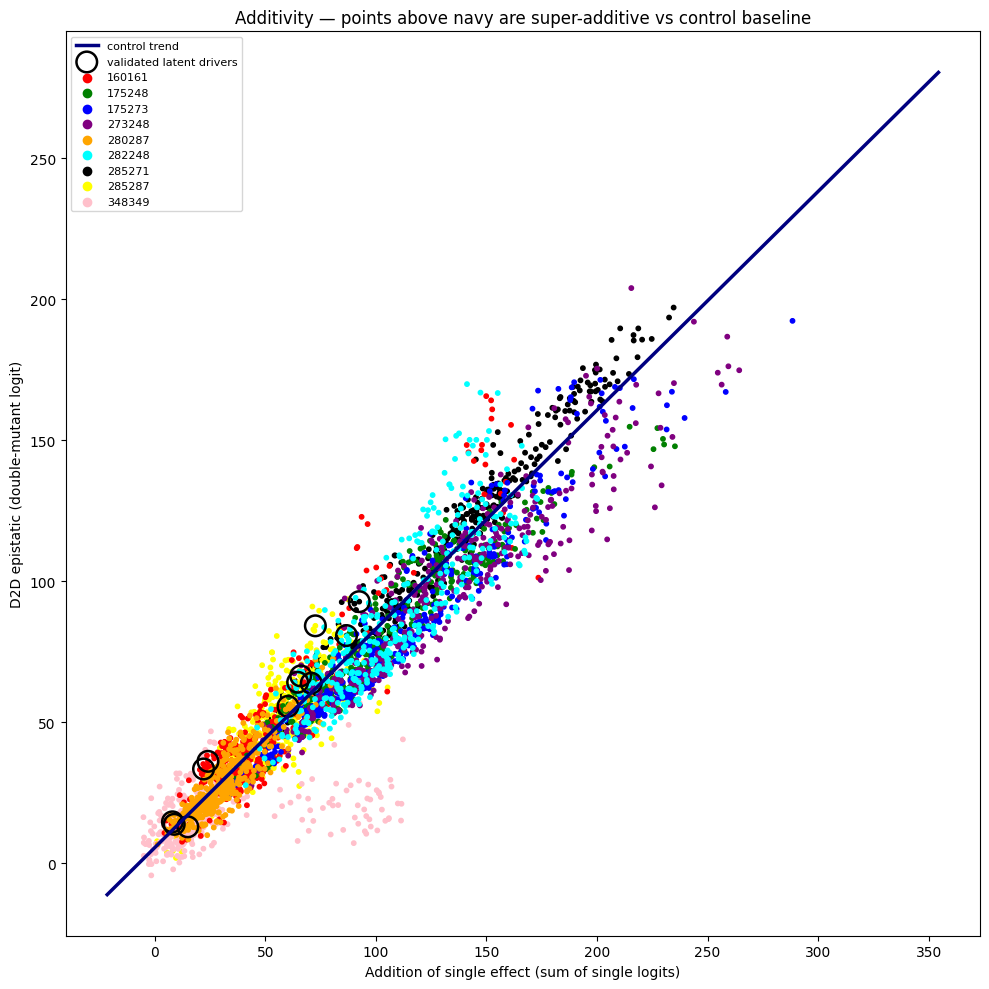

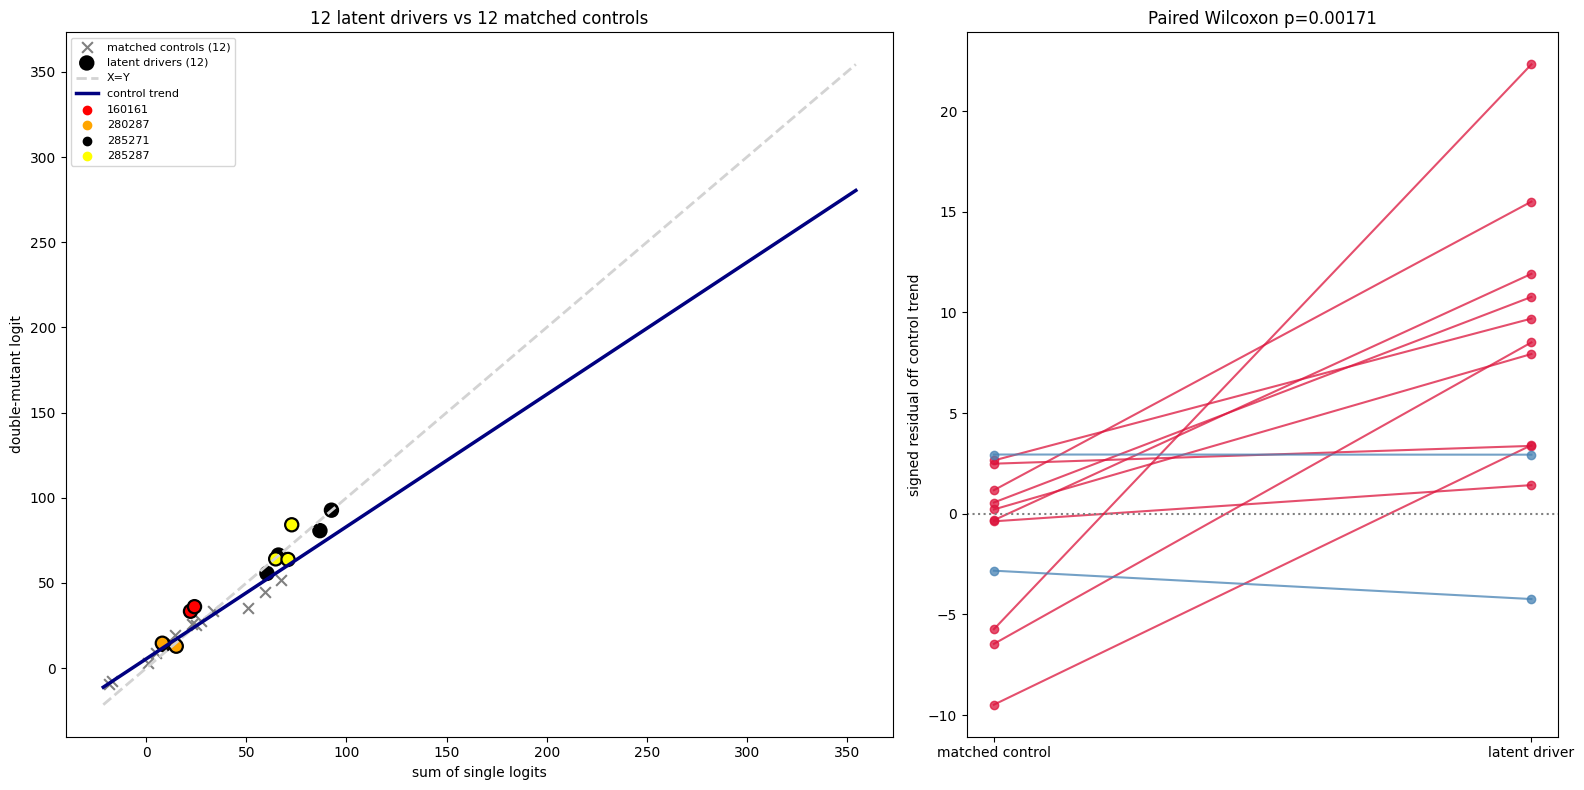

In [ ]:
import matplotlib.pyplot as plt

# (A) full additivity plot, epistatic colored by pair, drivers circled, X=Y + control trend
epi = epi_df[epi_df.group=='epistatic'].copy()
epi['category'] = epi['pair'].str.replace('_','',regex=False)
colors = epi['category'].map(category_to_color)
ctl = epi_df[epi_df.group=='control']

fig, ax = plt.subplots(figsize=(10,10))
# ax.scatter(ctl['single_sum_logit'], ctl['double_logit'], s=6, c='lightgray', alpha=.5, label='control')
ax.scatter(epi['single_sum_logit'], epi['double_logit'], s=10, c=colors.tolist())
xs = np.array([epi_df['single_sum_logit'].min(), epi_df['single_sum_logit'].max()])
#ax.plot(xs, xs, '--', color='gray', lw=3, label='X=Y (naive additive)')
ax.plot(xs, slope*xs+intercept, '-', color='navy', lw=2.5, label='control trend')
hit = epi[epi['mutation'].isin(latent_true)]
ax.scatter(hit['single_sum_logit'], hit['double_logit'], s=220, facecolors='none',
           edgecolors='black', linewidths=1.8, label='validated latent drivers')
ax.set_xlabel('Addition of single effect (sum of single logits)')
ax.set_ylabel('D2D epistatic (double-mutant logit)')
ax.set_title('Additivity — points above navy are super-additive vs control baseline')
for cat, col in category_to_color.items(): ax.scatter([], [], color=col, label=cat)
ax.legend(fontsize=8, loc='best'); plt.tight_layout(); plt.show()

# (B) focused 12v12: scatter + paired residual
lat_pts = epi_df[epi_df['mutation'].isin(latent_true)].copy()
lat_pts['category'] = lat_pts['pair'].str.replace('_','',regex=False)
ctrl_pts = pd.DataFrame([epi_df[(epi_df.group=='control') & (epi_df.pair==p)].iloc[i]
                          for p,i,_ in drawn])

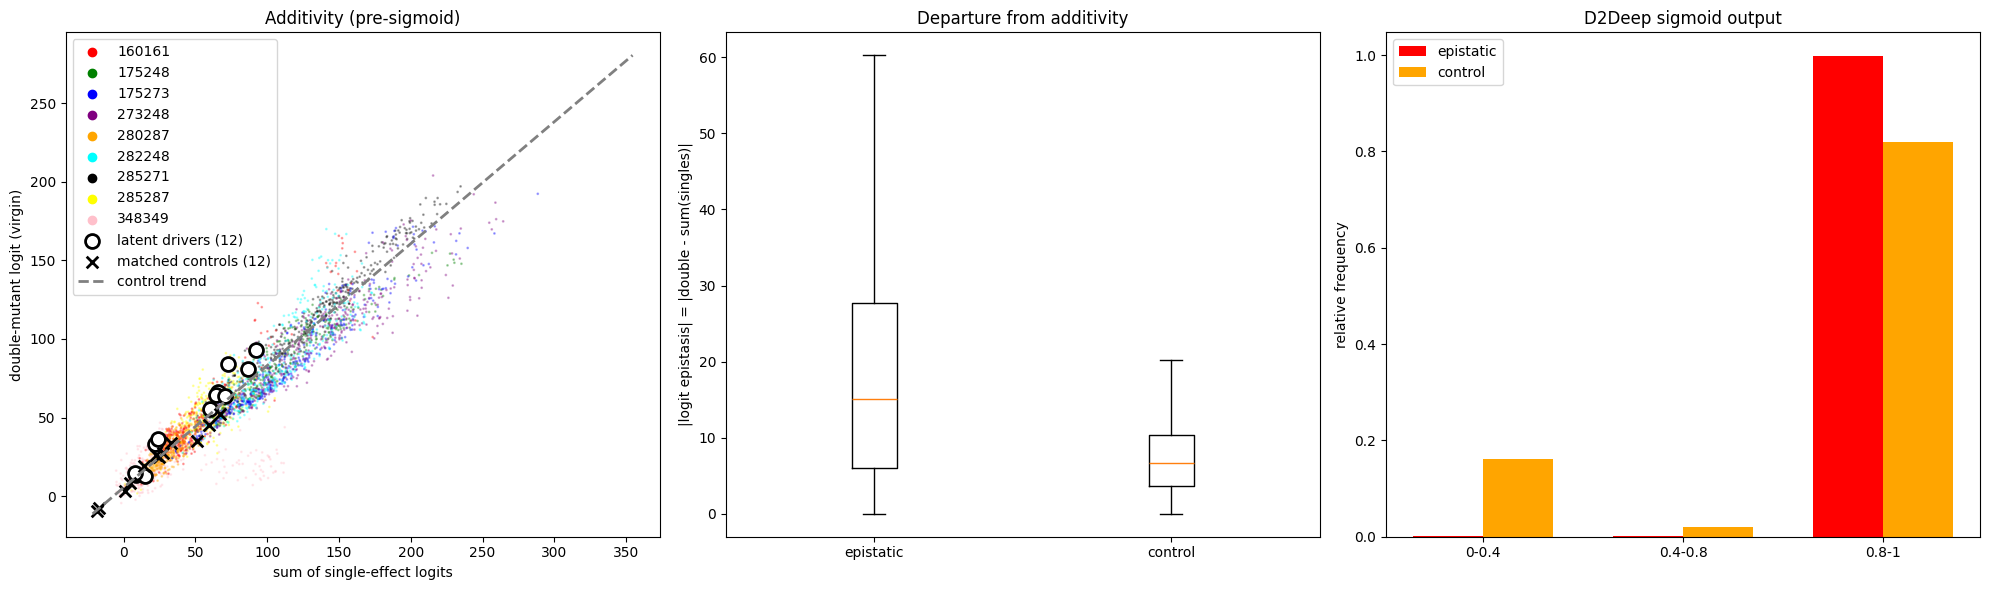

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# (a) additivity scatter in logit space (like test.ipynb, both groups)
#for g, col in [('control', 'orange'), ('epistatic', 'red')]:
#    s = epi_df[epi_df.group == g]
#    ax[0].scatter(s['single_sum_logit'], s['double_logit'], s=6, c=col, alpha=.5, label=g)
#lim = [epi_df[['single_sum_logit','double_logit']].values.min(),
#       epi_df[['single_sum_logit','double_logit']].values.max()]

ax[0].scatter(epi['single_sum_logit'], epi['double_logit'], s=1, c=colors.tolist(), alpha=0.3)
for cat, col in category_to_color.items(): ax[0].scatter([], [], color=col, label=cat)
ax[0].legend(fontsize=8, loc='best')
ax[0].scatter(lat_pts['single_sum_logit'], lat_pts['double_logit'], s=100,
           #c=lat_pts['category'].map(category_to_color).tolist(),
           c='white', edgecolors='black', linewidths=2, label='latent drivers (12)')
ax[0].scatter(ctrl_pts['single_sum_logit'], ctrl_pts['double_logit'], s=70, marker='x',
       c='black', linewidths=2, label='matched controls (12)')
#ax[0].plot(lim, lim, '--', c='gray', lw=2, label='X=Y (additive)')
ax[0].plot(xs, slope*xs+intercept, '--', color='gray', lw=2, label='control trend')
ax[0].set_xlabel('sum of single-effect logits'); ax[0].set_ylabel('double-mutant logit (virgin)')
ax[0].set_title('Additivity (pre-sigmoid)'); ax[0].legend()

# (b) epistasis-magnitude distribution per group
data = [epi_df.loc[epi_df.group=='epistatic','epistasis_logit'].abs(),
        epi_df.loc[epi_df.group=='control','epistasis_logit'].abs()]
ax[1].boxplot(data, labels=['epistatic', 'control'], showfliers=False)
ax[1].set_ylabel('|logit epistasis| = |double - sum(singles)|')
ax[1].set_title('Departure from additivity')

# (c) sigmoid range counts (relative freq), as in test.ipynb
def count_ranges(v):
    v = np.asarray(v)
    return [np.mean((v>=0)&(v<=0.4)), np.mean((v>0.4)&(v<=0.8)), np.mean((v>0.8)&(v<=1))]
cats = ['0-0.4', '0.4-0.8', '0.8-1']; x = np.arange(3); w = 0.35
ax[2].bar(x-w/2, count_ranges(epi_df.loc[epi_df.group=='epistatic','double_sigmoid']),  w, color='red',    label='epistatic')
ax[2].bar(x+w/2, count_ranges(epi_df.loc[epi_df.group=='control','double_sigmoid']),     w, color='orange', label='control')
ax[2].set_xticks(x); ax[2].set_xticklabels(cats); ax[2].set_ylabel('relative frequency')
ax[2].set_title('D2Deep sigmoid output'); ax[2].legend()

plt.tight_layout(); plt.show()

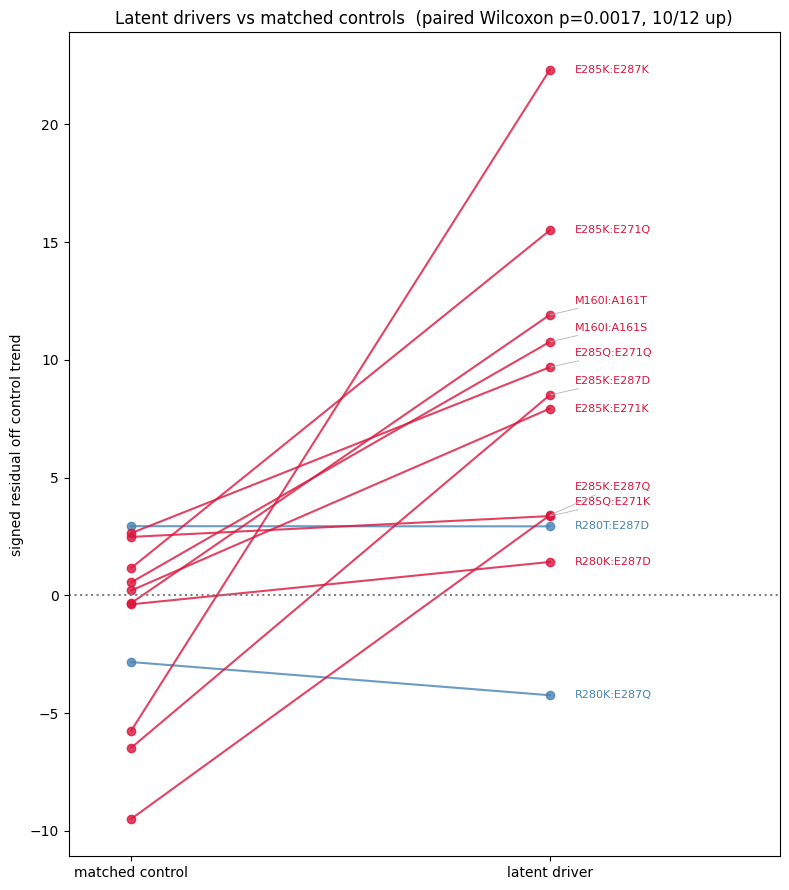

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# mutation label for each drawn pair, in the same row order as lat / lat_vals / ctrl_vals
lat_labels = [bare(m) for m in lat['mutation']]   # e.g. 'E285K:E271K'

fig, a2 = plt.subplots(figsize=(8, 9))
order = np.argsort(lat_vals)          # sort so vertically-close labels are handled predictably
seen_y = []
for k in order:
    d = lat_vals[k] - ctrl_vals[k]
    a2.plot([0, 1], [ctrl_vals[k], lat_vals[k]], '-o',
            color='crimson' if d > 0 else 'steelblue', alpha=.8, zorder=2)

    # anti-overlap: if this label's y is within 0.6 of one already placed, bump it up
    y = lat_vals[k]
    while any(abs(y - yy) < 0.6 for yy in seen_y):
        y += 0.6
    seen_y.append(y)

    a2.annotate(lat_labels[k], (1.0, lat_vals[k]),
                xytext=(1.06, y), fontsize=8, va='center', ha='left',
                color='crimson' if d > 0 else 'steelblue',
                arrowprops=dict(arrowstyle='-', color='0.7', lw=0.6,
                                shrinkA=0, shrinkB=0) if abs(y - lat_vals[k]) > 0.05 else None)
    # (optional) also label the control end:
    # a2.annotate(lat_labels[k], (0.0, ctrl_vals[k]), xytext=(-0.06, ctrl_vals[k]),
    #             fontsize=7, va='center', ha='right', color='0.5')

a2.axhline(0, ls=':', c='gray')
a2.set_xlim(-0.15, 1.55)
a2.set_xticks([0, 1]); a2.set_xticklabels(['matched control', 'latent driver'])
a2.set_ylabel('signed residual off control trend')
a2.set_title(f'Latent drivers vs matched controls  (paired Wilcoxon p={pw:.4f}, {int((lat_vals>ctrl_vals).sum())}/12 up)')
plt.tight_layout(); plt.show()

## §8 — Magnitude‑matched controls (rules out the site‑importance confound)

The driver‑vs‑control gap could be "hotspot positions simply have large single effects." This removes that: each validated driver is compared only against controls with a **similar single‑effect sum**, so single‑effect magnitude is held fixed and the only thing left is the interaction. Under the null (drivers behave like same‑magnitude non‑epistatic pairs), `P(driver > matched control)` is 0.5.

In [ ]:
from scipy.stats import wilcoxon

lat = epi_df[epi_df['mutation'].isin(latent_true)].copy()
ss = epi_df.loc[epi_df.group=='control', 'single_sum_logit'].values
yy = epi_df.loc[epi_df.group=='control', 'double_logit'].values

K = 50   # nearest controls by single-effect magnitude
rows = []
for _, d in lat.iterrows():
    diffs = np.abs(ss - d['single_sum_logit'])
    idx = np.argsort(diffs)[:K]
    rows.append({'mutation':bare(d['mutation']), 'pair':d['pair'],
                 'single_sum':round(d['single_sum_logit'],2),
                 'double_logit':round(d['double_logit'],2),
                 'ctrl_median':round(np.median(yy[idx]),2),
                 'prob_superiority':np.mean(d['double_logit'] > yy[idx]),
                 'max_mag_gap':round(diffs[idx].max(),2)})
mm = pd.DataFrame(rows)
W, p = wilcoxon(mm['prob_superiority']-0.5, alternative='greater')
print(f"Magnitude-matched (K={K} nearest controls by single-effect sum):")
print(f"  mean P(driver > matched control) = {mm['prob_superiority'].mean():.1%}")
print(f"  drivers with P>0.5: {(mm['prob_superiority']>0.5).sum()}/{len(mm)}")
print(f"  Wilcoxon (superiority > 0.5): W={W:.0f}, p={p:.4g}")
if (mm['max_mag_gap'] > 15).any():
    print("  ! some drivers sit outside the controls' magnitude range (max_mag_gap large) "
          "-> magnitude matching is weak there; interpret those rows cautiously")
print("\n", mm.to_string(index=False))

Magnitude-matched (K=50 nearest controls by single-effect sum):
  mean P(driver > matched control) = 73.2%
  drivers with P>0.5: 10/12
  Wilcoxon (superiority > 0.5): W=70, p=0.006104

    mutation    pair  single_sum  double_logit  ctrl_median  prob_superiority  max_mag_gap
E285K:E271K 285_271       86.73         80.68        75.66              0.66         4.85
E285K:E271Q 285_271       92.48         92.71        80.01              0.90         5.29
E285Q:E271K 285_271       60.26         55.58        52.95              0.56         1.63
E285Q:E271Q 285_271       66.01         66.37        57.38              0.88         1.83
E285K:E287D 285_287       64.63         64.11        56.20              0.86         1.92
E285K:E287K 285_287       72.64         84.13        67.51              0.90         2.09
E285K:E287Q 285_287       70.79         63.78        68.48              0.42         2.20
M160I:A161S 160_161       22.07         33.35        23.88              1.00         0.53
M160

## §9 — Within‑pair percentile (validated vs other substitutions at the *same* sites)

For each validated double, where does it fall in the full saturation cloud at its **own** position pair? This holds site and structure exactly fixed. Two readouts:

- **percentile → 1**: the validated substitutions are the *extreme* ones at that pair (a claim about coupled **substitutions**).
- **whole‑cloud median residual ≫ 0** while validated percentiles sit near 0.5: the *entire* pair is shifted up, validated or not — evidence the **position pair** is coupled and validation just labels a few members (a claim about coupled **sites**).

Both are informative; they're just different claims, so report whichever the data supports.

In [ ]:
rows = []
for _, d in lat.iterrows():
    cl = epi_df[epi_df.pair == d['pair']]['trend_resid'].values
    rows.append({'mutation':bare(d['mutation']), 'pair':d['pair'],
                 'trend_resid':round(d['trend_resid'],2),
                 'pair_cloud_median':round(np.median(cl),2),
                 'percentile':np.mean(cl <= d['trend_resid'])})
wp = pd.DataFrame(rows)
W, p = wilcoxon(wp['percentile']-0.5, alternative='greater')
print("Within-pair percentile of validated doubles (trend_resid vs same-pair saturation cloud):")
print(f"  mean percentile = {wp['percentile'].mean():.1%}   (0.5 = typical member; ->1 = extreme)")
print(f"  Wilcoxon (percentile > 0.5): W={W:.0f}, p={p:.4g}\n")
print(wp.to_string(index=False))

print("\nWhole-cloud shift per pair (site-coupling signal; >0 means the pair sits above the control baseline):")
for pr in sorted(set(lat['pair'])):
    cl = epi_df[epi_df.pair==pr]['trend_resid']
    print(f"  pair {pr}: cloud median resid = {cl.median():+.2f}  (n={len(cl)})")

Within-pair percentile of validated doubles (trend_resid vs same-pair saturation cloud):
  mean percentile = 71.1%   (0.5 = typical member; ->1 = extreme)
  Wilcoxon (percentile > 0.5): W=71, p=0.004395

   mutation    pair  trend_resid  pair_cloud_median  percentile
E285K:E271K 285_271         7.93               4.85    0.686981
E285K:E271Q 285_271        15.50               4.85    0.925208
E285Q:E271K 285_271         3.37               4.85    0.415512
E285Q:E271Q 285_271         9.69               4.85    0.767313
E285K:E287D 285_287         8.51               1.43    0.753463
E285K:E287K 285_287        22.32               1.43    0.977839
E285K:E287Q 285_287         3.41               1.43    0.576177
M160I:A161S 160_161        10.77               2.40    0.833795
M160I:A161T 160_161        11.92               2.40    0.883657
R280K:E287D 280_287         1.42              -1.28    0.650970
R280K:E287Q 280_287        -4.24              -1.28    0.307479
R280T:E287D 280_287         

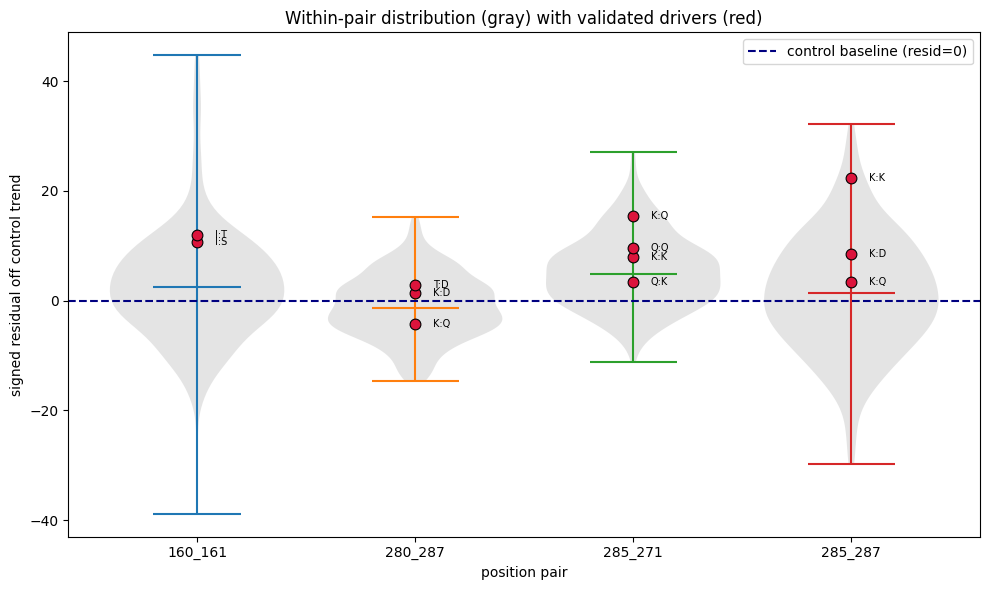

In [ ]:
# distribution of each validated pair's saturation cloud, with validated doubles overlaid
pairs = sorted(set(lat['pair']))
fig, ax = plt.subplots(figsize=(10, 6))
for i, pr in enumerate(pairs):
    cl = epi_df[epi_df.pair==pr]['trend_resid'].values
    parts = ax.violinplot(cl, positions=[i], widths=0.8, showmedians=True)
    for b in parts['bodies']:
        b.set_facecolor('lightgray'); b.set_alpha(0.6)
    v = lat[lat.pair==pr]
    ax.scatter([i]*len(v), v['trend_resid'], color='crimson', s=60, zorder=3,
               edgecolors='black', linewidths=0.8)
    for _, d in v.iterrows():
        ax.annotate(bare(d['mutation']).split(':')[0][-1]+':'+bare(d['mutation']).split(':')[1][-1],
                    (i, d['trend_resid']), xytext=(i+0.08, d['trend_resid']),
                    fontsize=7, va='center')
ax.axhline(0, ls='--', c='navy', label='control baseline (resid=0)')
ax.set_xticks(range(len(pairs))); ax.set_xticklabels(pairs)
ax.set_ylabel('signed residual off control trend')
ax.set_xlabel('position pair')
ax.set_title('Within-pair distribution (gray) with validated drivers (red)')
ax.legend(); plt.tight_layout(); plt.show()